# Aula 04: Problemas de Localização de Instalações

Nesta aula, abordaremos decisões estratégicas de longo prazo: **onde instalar facildades?** (fábricas, armazéns, antenas, hospitais).

Diferente do transporte (tático), a localização define a estrutura da rede. Exploraremos modelos clássicos como o P-Mediana e o P-Hub.

<div align="center">
  <img src="img/localizacao.png" width="600px" />
  <p><i>Conceito de Localização de Facilidades e Clusterização de Demanda</i></p>
</div>

## 1. O Problema das P-Medianas (P-Median Problem)

O objetivo é selecionar $P$ locais para instalar facilidades, entre $n$ locais candidatos, de modo a minimizar a soma das distâncias ponderadas entre os clientes e a facilidade mais próxima.

### Aplicações:
- Localização de postos de saúde (minimizar distância percorrida pelo cidadão).
- Armazéns de e-commerce (minimizar tempo de entrega).

### Modelo Matemático:
**Variáveis:**
- $y_j = 1$ se instalarmos uma facilidade no local $j$; $0$ caso contrário.
- $x_{ij} = 1$ se o cliente $i$ for atendido pela facilidade $j$; $0$ caso contrário.

**Função Objetivo:**
Minimizar $Z = \sum_{i} \sum_{j} w_i d_{ij} x_{ij}$
Onde $w_i$ é o peso/demanda do cliente $i$ e $d_{ij}$ é a distância.

**Restrições:**
1. Cada cliente deve ser atendido por exatamente uma facilidade: $\sum_{j} x_{ij} = 1, \quad \forall i$
2. Um cliente só pode ser atendido por $j$ se a facilidade $j$ existir: $x_{ij} \leq y_j, \quad \forall i, j$
3. Devemos instalar exatamente $P$ facilidades: $\sum_{j} y_j = P$
4. Variáveis binárias: $x_{ij}, y_j \in \{0, 1\}$

## 2. Implementação com PuLP

Resolveremos um problema com 7 pontos de demanda, onde queremos escolher as 2 melhores localizações ($P=2$).

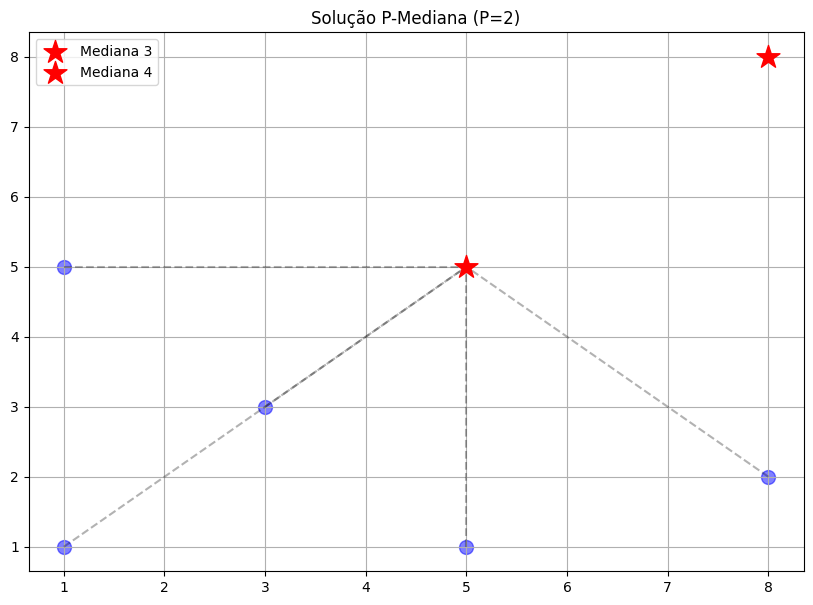

Distância Ponderada Total: 253.14


In [1]:
import pulp
import math
import json
import matplotlib.pyplot as plt

# Carregar dados da instância
try:
    with open('data/localizacao.json', 'r') as f:
        data = json.load(f)['p_mediana']
except:
    data = {
        "pontos_demanda": [
            {"id": 0, "x": 1, "y": 1, "peso": 10},
            {"id": 1, "x": 1, "y": 5, "peso": 20},
            {"id": 2, "x": 5, "y": 1, "peso": 15},
            {"id": 3, "x": 5, "y": 5, "peso": 30},
            {"id": 4, "x": 8, "y": 8, "peso": 25},
            {"id": 5, "x": 8, "y": 2, "peso": 10},
            {"id": 6, "x": 3, "y": 3, "peso": 5}
        ],
        "p": 2
    }

pontos = data['pontos_demanda']
P = data['p']
n = len(pontos)

def dist(i, j):
    return math.sqrt((pontos[i]['x'] - pontos[j]['x'])**2 + (pontos[i]['y'] - pontos[j]['y'])**2)

# 1. Criar o problema
prob = pulp.LpProblem("P_Mediana", pulp.LpMinimize)

# 2. Variáveis
y = pulp.LpVariable.dicts("Facilidade", range(n), cat='Binary')
x = pulp.LpVariable.dicts("Atendimento", (range(n), range(n)), cat='Binary')

# 3. Função Objetivo
prob += pulp.lpSum(pontos[i]['peso'] * dist(i, j) * x[i][j] for i in range(n) for j in range(n))

# 4. Restrições
for i in range(n):
    prob += pulp.lpSum(x[i][j] for j in range(n)) == 1
for i in range(n):
    for j in range(n):
        prob += x[i][j] <= y[j]
prob += pulp.lpSum(y[j] for j in range(n)) == P

# 5. Resolver
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# 6. Visualização
plt.figure(figsize=(10, 7))
for j in range(n):
    if pulp.value(y[j]) == 1:
        plt.scatter(pontos[j]['x'], pontos[j]['y'], s=300, c='red', marker='*', label=f'Mediana {j}', zorder=5)
    else:
        plt.scatter(pontos[j]['x'], pontos[j]['y'], s=100, c='blue', alpha=0.5)

for i in range(n):
    for j in range(n):
        if pulp.value(x[i][j]) == 1:
            plt.plot([pontos[i]['x'], pontos[j]['x']], [pontos[i]['y'], pontos[j]['y']], 'k--', alpha=0.3)

plt.title(f"Solução P-Mediana (P={P})")
plt.legend()
plt.grid(True)
plt.show()

print(f"Distância Ponderada Total: {pulp.value(prob.objective):.2f}")

## 3. P-Hub Location Problem

Em redes de transporte aéreo ou telecomunicações, não faz sentido conectar todas as cidades entre si. Usamos **Hubs**.

### Características:
- Fluxos entre cidades não-hub devem passar por um ou dois hubs.
- Existe um fator de desconto (economias de escala) no transporte entre hubs.
- **P-Hub Median**: Minimiza o custo total de transporte escolhendo $P$ hubs.

### Diferença chave:
Enquanto o P-Mediana foca na proximidade Ponto-Facilidade, o P-Hub foca na eficiência do fluxo Ponto-Hub-Hub-Ponto.

## 4. Análise de Sensibilidade na Localização

### Exercício 1: Impacto do Valor de P
No código acima, altere `P` de **2** para **3**. 
- Como a distância total muda? 
- A localização das facilidades anteriores se manteve a mesma ou o solver escolheu locais completamente diferentes?

### Exercício 2: Pesos de Demanda
Altere o peso do **Ponto 0** (id 0) de **10** para **500**.
- O que aconteceu com a mediana mais próxima a esse ponto? 
- Explique por que pontos com muita demanda "atraem" as facilidades para perto de si no modelo P-Mediana.